# Comparing GS-family algorithms for Fourier holography

This notebook benchmarks several simple Gerchberg–Saxton (GS) variants for a phase-only SLM.

The goal is not to hide the physics behind a library. The core algorithms are implemented directly with `numpy.fft`, so you can inspect and modify every line. There is also an optional `slmsuite` import check near the end, because `slmsuite` is useful for real experimental holography, GPU acceleration, feedback, and more advanced WGS methods.

## What this notebook compares

1. **GS** — classic amplitude replacement in the Fourier plane.
2. **Adaptive-additive GS** — a relaxed version that only partially replaces the Fourier amplitude each iteration.
3. **MRAF-like GS** — constrains the target region, while letting the noise region float.
4. **Weighted GS / WGS-like** — iteratively reweights bright target pixels to improve amplitude uniformity.
5. **Multi-start GS** — repeats plain GS with different random initial phases and keeps the best run.

## Main outputs

- overlaid convergence curves for all methods
- efficiency curves for all methods
- final reconstructed amplitude for each method
- final phase mask for each method
- optional 16-bit phase export helper for a Meadowlark-style SLM workflow

The benchmark is button-driven, not auto-updating, to avoid the “endless loop” behavior from interactive widgets.

In [1]:
# Core imports
import time
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Dict, List, Tuple

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False
    print("ipywidgets is not available. You can still run the non-interactive cells.")

try:
    from PIL import Image, ImageDraw, ImageFont
    HAS_PIL = True
except Exception:
    HAS_PIL = False
    print("PIL/Pillow is not available. Some target generators will be disabled.")

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["image.cmap"] = "viridis"

DEFAULT_SEED = 7

## 1. FFT conventions

We use a simple Fourier-plane model:

\[
E_f = \mathcal{F}\{A_{\mathrm{in}} e^{i\phi_{\mathrm{SLM}}}\}
\]

where `input_amp` is the fixed near-field beam amplitude at the SLM. In the lab this might be Gaussian and clipped by the SLM aperture. In the most naive simulation, it is often set to a flat top.

The algorithms update only the phase sent to the SLM, while the near-field amplitude is always reset to `input_amp`.

In [2]:
def fft2c(x: np.ndarray) -> np.ndarray:
    """Centered FFT for plotting-friendly Fourier holography."""
    return np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(x), norm="ortho"))

def ifft2c(x: np.ndarray) -> np.ndarray:
    """Inverse centered FFT."""
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(x), norm="ortho"))

def normalize01(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    x = x - np.nanmin(x)
    mx = np.nanmax(x)
    return x / (mx + eps)

def gaussian_input_amp(N: int, waist_fraction: float = 0.33, clip: bool = True) -> np.ndarray:
    yy, xx = np.indices((N, N))
    cx = cy = (N - 1) / 2
    r2 = (xx - cx)**2 + (yy - cy)**2
    waist_px = waist_fraction * (N / 2)
    amp = np.exp(-r2 / waist_px**2)
    if clip:
        aperture = r2 <= (0.48 * N)**2
        amp = amp * aperture
    return amp / (amp.max() + 1e-12)

def flat_input_amp(N: int) -> np.ndarray:
    return np.ones((N, N), dtype=float)

## 2. Target amplitude generators

In [3]:
def target_spots(N: int, num_spots: int = 9, radius: int = 2, spread: float = 0.28) -> np.ndarray:
    yy, xx = np.indices((N, N))
    cx = cy = (N - 1) / 2
    coords = []
    side = int(np.ceil(np.sqrt(num_spots)))
    spacing = spread * N / max(side - 1, 1)
    start = -(side - 1) * spacing / 2
    for iy in range(side):
        for ix in range(side):
            if len(coords) >= num_spots:
                break
            coords.append((cx + start + ix * spacing, cy + start + iy * spacing))
    amp = np.zeros((N, N), dtype=float)
    sigma = max(radius, 1)
    for x0, y0 in coords:
        amp += np.exp(-((xx - x0)**2 + (yy - y0)**2) / (2 * sigma**2))
    return amp / (amp.max() + 1e-12)

def target_ring(N: int, radius_fraction: float = 0.20, width_fraction: float = 0.025) -> np.ndarray:
    yy, xx = np.indices((N, N))
    cx = cy = (N - 1) / 2
    rr = np.sqrt((xx - cx)**2 + (yy - cy)**2)
    r0 = radius_fraction * N
    width = max(width_fraction * N, 1)
    amp = np.exp(-((rr - r0)**2) / (2 * width**2))
    return amp / (amp.max() + 1e-12)

def target_hg11_intensity_amp(N: int, waist_fraction: float = 0.18) -> np.ndarray:
    yy, xx = np.indices((N, N))
    x = (xx - (N - 1) / 2) / (N / 2)
    y = (yy - (N - 1) / 2) / (N / 2)
    w = waist_fraction
    field = (x / w) * (y / w) * np.exp(-(x**2 + y**2) / w**2)
    intensity = field**2
    amp = np.sqrt(intensity)
    return amp / (amp.max() + 1e-12)

def target_letter(N: int, text: str = "E") -> np.ndarray:
    if not HAS_PIL:
        raise RuntimeError("Pillow is required for the letter target.")
    img = Image.new("L", (N, N), 0)
    draw = ImageDraw.Draw(img)
    try:
        font = ImageFont.truetype("DejaVuSans-Bold.ttf", int(0.72 * N))
    except Exception:
        font = ImageFont.load_default()
    bbox = draw.textbbox((0, 0), text, font=font)
    tw, th = bbox[2] - bbox[0], bbox[3] - bbox[1]
    draw.text(((N - tw) / 2, (N - th) / 2 - 0.06 * N), text, fill=255, font=font)
    arr = np.asarray(img, dtype=float) / 255
    for _ in range(2):
        arr = (
            arr
            + np.roll(arr, 1, 0) + np.roll(arr, -1, 0)
            + np.roll(arr, 1, 1) + np.roll(arr, -1, 1)
        ) / 5
    return arr / (arr.max() + 1e-12)

def make_target(name: str, N: int) -> np.ndarray:
    name = name.lower()
    if name == "spots":
        return target_spots(N, num_spots=9, radius=max(1, N // 128), spread=0.34)
    if name == "ring":
        return target_ring(N)
    if name == "hg11":
        return target_hg11_intensity_amp(N)
    if name == "letter":
        return target_letter(N, "E")
    raise ValueError(f"Unknown target: {name}")

## 3. Metrics

All methods are judged with the same metrics at every iteration.

In [4]:
def make_signal_mask(target_amp: np.ndarray, threshold: float = 0.08) -> np.ndarray:
    """Pixels considered part of the useful target region."""
    return target_amp > threshold * target_amp.max()

def normalized_amplitude_error(recon_amp: np.ndarray, target_amp: np.ndarray, mask: np.ndarray, eps: float = 1e-12) -> float:
    """Scale-invariant RMS amplitude error inside the target/signal region. Lower is better."""
    r = recon_amp[mask].astype(float)
    t = target_amp[mask].astype(float)
    if r.size == 0:
        return np.nan
    scale = np.sum(r * t) / (np.sum(r * r) + eps)
    diff = scale * r - t
    return float(np.sqrt(np.mean(diff**2)) / (np.sqrt(np.mean(t**2)) + eps))

def amplitude_overlap(recon_amp: np.ndarray, target_amp: np.ndarray, mask: np.ndarray, eps: float = 1e-12) -> float:
    """Normalized amplitude overlap inside the target/signal region. Higher is better."""
    r = recon_amp[mask].astype(float)
    t = target_amp[mask].astype(float)
    return float(np.sum(r * t) / (np.sqrt(np.sum(r**2) * np.sum(t**2)) + eps))

def power_efficiency(far_field: np.ndarray, mask: np.ndarray, eps: float = 1e-12) -> float:
    """Fraction of total Fourier-plane power that lands in the signal region."""
    power = np.abs(far_field)**2
    return float(np.sum(power[mask]) / (np.sum(power) + eps))

def spot_uniformity(recon_amp: np.ndarray, target_amp: np.ndarray, mask: np.ndarray, eps: float = 1e-12) -> float:
    """For sparse spot targets: std/mean for reconstructed amplitudes at bright target pixels. Lower is better."""
    bright = target_amp > 0.75 * target_amp.max()
    bright = bright & mask
    vals = recon_amp[bright]
    if vals.size < 2:
        return np.nan
    return float(np.std(vals) / (np.mean(vals) + eps))

def compute_metrics(far_field: np.ndarray, target_amp: np.ndarray, mask: np.ndarray) -> Dict[str, float]:
    amp = np.abs(far_field)
    return {
        "error": normalized_amplitude_error(amp, target_amp, mask),
        "overlap": amplitude_overlap(amp, target_amp, mask),
        "efficiency": power_efficiency(far_field, mask),
        "uniformity": spot_uniformity(amp, target_amp, mask),
    }

## 4. Algorithm implementations

In [5]:
@dataclass
class RunResult:
    name: str
    phase: np.ndarray
    far_field: np.ndarray
    metrics: Dict[str, List[float]]
    elapsed_s: float
    notes: str = ""

def initial_phase(shape: Tuple[int, int], seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    return rng.uniform(0, 2*np.pi, shape)

def normalize_desired_amp(desired: np.ndarray, target_amp: np.ndarray, mask: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    out = desired.copy()
    mean_target = np.mean(target_amp[mask]) + eps
    mean_desired = np.mean(out[mask]) + eps
    out[mask] *= mean_target / mean_desired
    return out

def run_gs_variant(
    name: str,
    target_amp: np.ndarray,
    input_amp: np.ndarray,
    iterations: int = 50,
    seed: int = DEFAULT_SEED,
    mask_threshold: float = 0.08,
    aa_beta: float = 0.7,
    mraf_noise_factor: float = 1.0,
    wgs_alpha: float = 0.6,
    verbose: bool = False,
) -> RunResult:
    target_amp = target_amp.astype(float)
    input_amp = input_amp.astype(float)
    mask = make_signal_mask(target_amp, threshold=mask_threshold)
    noise = ~mask

    phase = initial_phase(target_amp.shape, seed)
    weights = np.ones_like(target_amp)

    hist = {"error": [], "overlap": [], "efficiency": [], "uniformity": []}
    t0 = time.perf_counter()

    for it in range(iterations):
        near = input_amp * np.exp(1j * phase)
        far = fft2c(near)

        metrics = compute_metrics(far, target_amp, mask)
        for k, v in metrics.items():
            hist[k].append(v)

        current_amp = np.abs(far)
        current_phase = np.angle(far)

        lname = name.lower()

        if lname == "gs":
            # Strictly replace amplitude everywhere.
            new_amp = target_amp

        elif lname == "adaptive":
            # Relaxed replacement everywhere.
            # beta=1 gives standard GS. Smaller beta changes amplitude more gently.
            new_amp = (1 - aa_beta) * current_amp + aa_beta * target_amp

        elif lname == "mraf":
            # Mixed-region amplitude freedom:
            # constrain target region; outside, let the field keep its current amplitude.
            new_amp = np.empty_like(target_amp)
            new_amp[mask] = target_amp[mask]
            new_amp[noise] = mraf_noise_factor * current_amp[noise]

        elif lname == "wgs":
            # Simple WGS-like update:
            # underpowered target pixels get larger weights; overpowered pixels get smaller weights.
            ratio = target_amp[mask] / (current_amp[mask] + 1e-12)
            weights[mask] *= np.clip(ratio, 0.2, 5.0) ** wgs_alpha
            desired = target_amp * weights
            desired = normalize_desired_amp(desired, target_amp, mask)
            new_amp = np.empty_like(target_amp)
            new_amp[mask] = desired[mask]
            new_amp[noise] = current_amp[noise]

        else:
            raise ValueError(f"Unknown method: {name}")

        far_new = new_amp * np.exp(1j * current_phase)
        near_new = ifft2c(far_new)

        # Phase-only SLM constraint in the near field.
        phase = np.angle(near_new)

        if verbose and (it % 10 == 0 or it == iterations - 1):
            print(f"{name:>10s} iter {it:03d}: error={hist['error'][-1]:.4f}, eff={hist['efficiency'][-1]:.3f}")

    far = fft2c(input_amp * np.exp(1j * phase))
    final_metrics = compute_metrics(far, target_amp, mask)
    for k, v in final_metrics.items():
        hist[k].append(v)

    elapsed = time.perf_counter() - t0
    return RunResult(name=name, phase=phase, far_field=far, metrics=hist, elapsed_s=elapsed)

def run_multistart_gs(
    target_amp: np.ndarray,
    input_amp: np.ndarray,
    iterations: int = 50,
    seeds: List[int] = [1, 2, 3, 4],
    mask_threshold: float = 0.08,
) -> RunResult:
    """Run plain GS several times and keep the best final error."""
    runs = [
        run_gs_variant("GS", target_amp, input_amp, iterations, seed=s, mask_threshold=mask_threshold)
        for s in seeds
    ]
    best_idx = int(np.argmin([r.metrics["error"][-1] for r in runs]))
    best = runs[best_idx]
    best.name = f"Multi-start GS ({len(seeds)} seeds)"
    best.notes = f"Kept seed {seeds[best_idx]} with lowest final error."
    return best

## 5. Benchmark runner

In [6]:
def run_benchmark(
    target_name: str = "spots",
    N: int = 256,
    iterations: int = 60,
    input_kind: str = "gaussian",
    seed: int = DEFAULT_SEED,
    mask_threshold: float = 0.08,
    include_multistart: bool = True,
) -> Dict[str, RunResult]:
    """Run all methods on the same target and input beam."""
    target_amp = make_target(target_name, N)

    if input_kind.lower() == "gaussian":
        input_amp = gaussian_input_amp(N, waist_fraction=0.55)
    elif input_kind.lower() == "flat":
        input_amp = flat_input_amp(N)
    else:
        raise ValueError("input_kind must be 'gaussian' or 'flat'.")

    methods = {
        "GS": lambda: run_gs_variant("GS", target_amp, input_amp, iterations, seed=seed, mask_threshold=mask_threshold),
        "Adaptive": lambda: run_gs_variant("Adaptive", target_amp, input_amp, iterations, seed=seed, mask_threshold=mask_threshold, aa_beta=0.65),
        "MRAF": lambda: run_gs_variant("MRAF", target_amp, input_amp, iterations, seed=seed, mask_threshold=mask_threshold, mraf_noise_factor=1.0),
        "WGS": lambda: run_gs_variant("WGS", target_amp, input_amp, iterations, seed=seed, mask_threshold=mask_threshold, wgs_alpha=0.6),
    }

    results = {}
    for method_name, runner in methods.items():
        results[method_name] = runner()

    if include_multistart:
        results["Multi-start GS"] = run_multistart_gs(
            target_amp, input_amp, iterations, seeds=[seed, seed+1, seed+2, seed+3], mask_threshold=mask_threshold
        )

    results["_target_amp"] = target_amp
    results["_input_amp"] = input_amp
    results["_mask"] = make_signal_mask(target_amp, threshold=mask_threshold)
    return results

def print_summary_table(results: Dict[str, RunResult]) -> None:
    print(f"{'method':<24} {'error↓':>10} {'overlap↑':>10} {'efficiency↑':>13} {'uniformity↓':>13} {'time [s]':>10}")
    print("-" * 90)
    for name, r in results.items():
        if name.startswith("_"):
            continue
        uni = r.metrics["uniformity"][-1]
        uni_str = "nan" if np.isnan(uni) else f"{uni:.4f}"
        print(f"{r.name:<24} {r.metrics['error'][-1]:10.4f} {r.metrics['overlap'][-1]:10.4f} {r.metrics['efficiency'][-1]:13.4f} {uni_str:>13} {r.elapsed_s:10.3f}")
        if r.notes:
            print(f"  note: {r.notes}")

## 6. Plotting functions

In [7]:
def plot_target_and_input(results: Dict[str, RunResult]) -> None:
    target_amp = results["_target_amp"]
    input_amp = results["_input_amp"]
    mask = results["_mask"]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(input_amp)
    axes[0].set_title("Input amplitude at SLM")
    axes[1].imshow(target_amp)
    axes[1].set_title("Target amplitude")
    axes[2].imshow(mask)
    axes[2].set_title("Signal mask")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

def plot_convergence(results: Dict[str, RunResult]) -> None:
    plt.figure(figsize=(8, 5))
    for name, r in results.items():
        if name.startswith("_"):
            continue
        plt.plot(r.metrics["error"], label=r.name)
    plt.xlabel("Iteration")
    plt.ylabel("Normalized amplitude error")
    plt.title("Convergence comparison: amplitude error")
    plt.yscale("log")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_efficiency(results: Dict[str, RunResult]) -> None:
    plt.figure(figsize=(8, 5))
    for name, r in results.items():
        if name.startswith("_"):
            continue
        plt.plot(r.metrics["efficiency"], label=r.name)
    plt.xlabel("Iteration")
    plt.ylabel("Power fraction in signal region")
    plt.title("Convergence comparison: diffraction efficiency proxy")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_overlap(results: Dict[str, RunResult]) -> None:
    plt.figure(figsize=(8, 5))
    for name, r in results.items():
        if name.startswith("_"):
            continue
        plt.plot(r.metrics["overlap"], label=r.name)
    plt.xlabel("Iteration")
    plt.ylabel("Amplitude overlap")
    plt.title("Convergence comparison: normalized overlap")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_final_amplitudes(results: Dict[str, RunResult], vmax_percentile: float = 99.5) -> None:
    target_amp = results["_target_amp"]
    method_items = [(n, r) for n, r in results.items() if not n.startswith("_")]
    ncols = 3
    nrows = int(np.ceil((len(method_items) + 1) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
    axes = np.array(axes).reshape(-1)

    axes[0].imshow(target_amp)
    axes[0].set_title("Target amplitude")
    axes[0].axis("off")

    for ax, (name, r) in zip(axes[1:], method_items):
        amp = np.abs(r.far_field)
        vmax = np.percentile(amp, vmax_percentile)
        ax.imshow(amp, vmin=0, vmax=vmax)
        ax.set_title(f"{r.name}\nerr={r.metrics['error'][-1]:.3g}, eff={r.metrics['efficiency'][-1]:.2f}")
        ax.axis("off")

    for ax in axes[len(method_items)+1:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

def plot_final_phases(results: Dict[str, RunResult]) -> None:
    method_items = [(n, r) for n, r in results.items() if not n.startswith("_")]
    ncols = 3
    nrows = int(np.ceil(len(method_items) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
    axes = np.array(axes).reshape(-1)

    for ax, (name, r) in zip(axes, method_items):
        ax.imshow(np.mod(r.phase, 2*np.pi), vmin=0, vmax=2*np.pi, cmap="twilight")
        ax.set_title(r.name)
        ax.axis("off")

    for ax in axes[len(method_items):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

def plot_all(results: Dict[str, RunResult]) -> None:
    plot_target_and_input(results)
    print_summary_table(results)
    plot_convergence(results)
    plot_efficiency(results)
    plot_overlap(results)
    plot_final_amplitudes(results)
    plot_final_phases(results)

## 7. Run a default benchmark

This cell is deliberately not huge by default. Start with `N=256`; switch to `N=512` when you want something closer to your Meadowlark P512 grid.

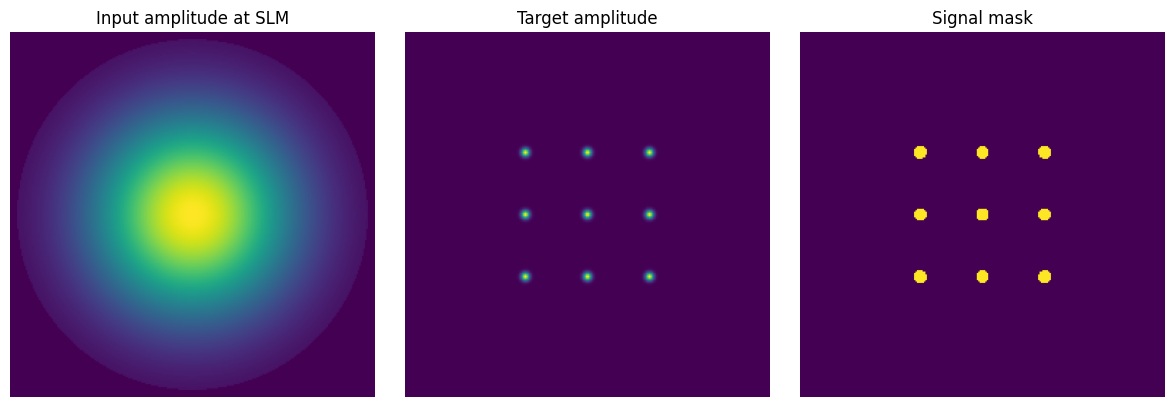

method                       error↓   overlap↑   efficiency↑   uniformity↓   time [s]
------------------------------------------------------------------------------------------
GS                           0.1011     0.9949        0.9129        0.1163      2.749
Adaptive                     0.1561     0.9877        0.8796        0.1500      1.862
MRAF                         0.0031     1.0000        0.0145        0.0869      3.097
WGS                          0.0042     1.0000        0.0145        0.0879      3.031
Multi-start GS (4 seeds)     0.0887     0.9961        0.9138        0.1060      1.469
  note: Kept seed 10 with lowest final error.


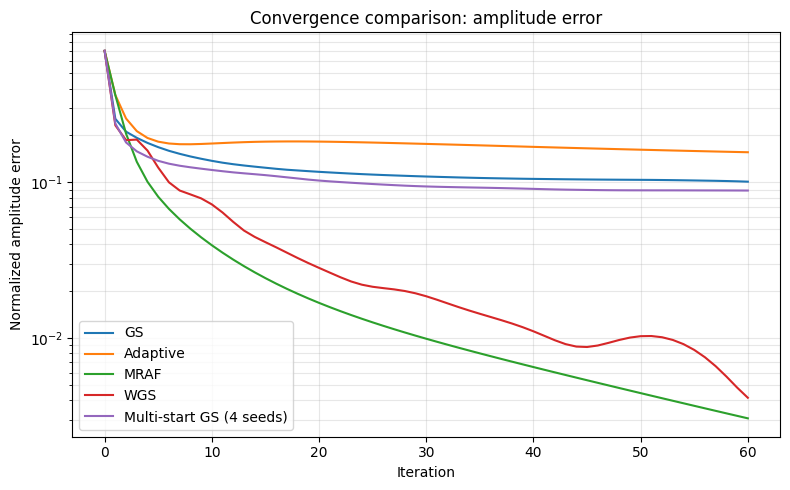

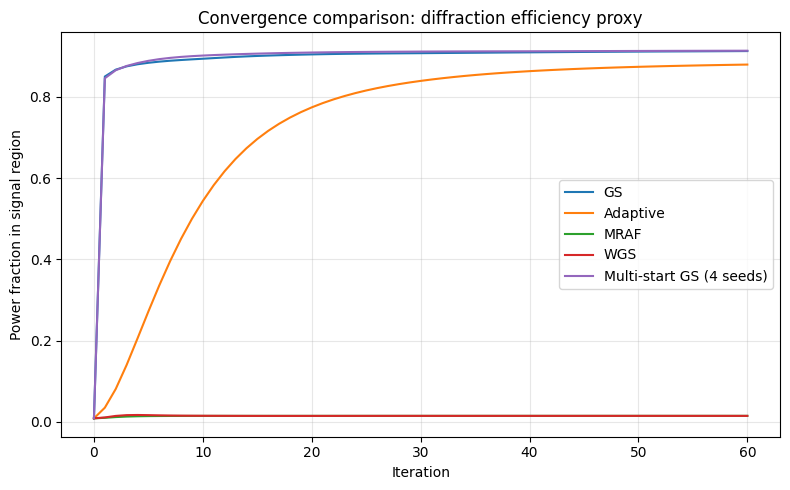

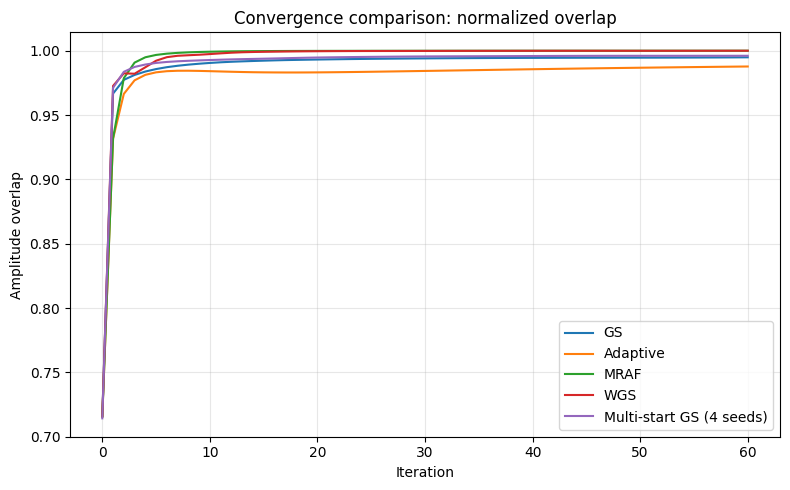

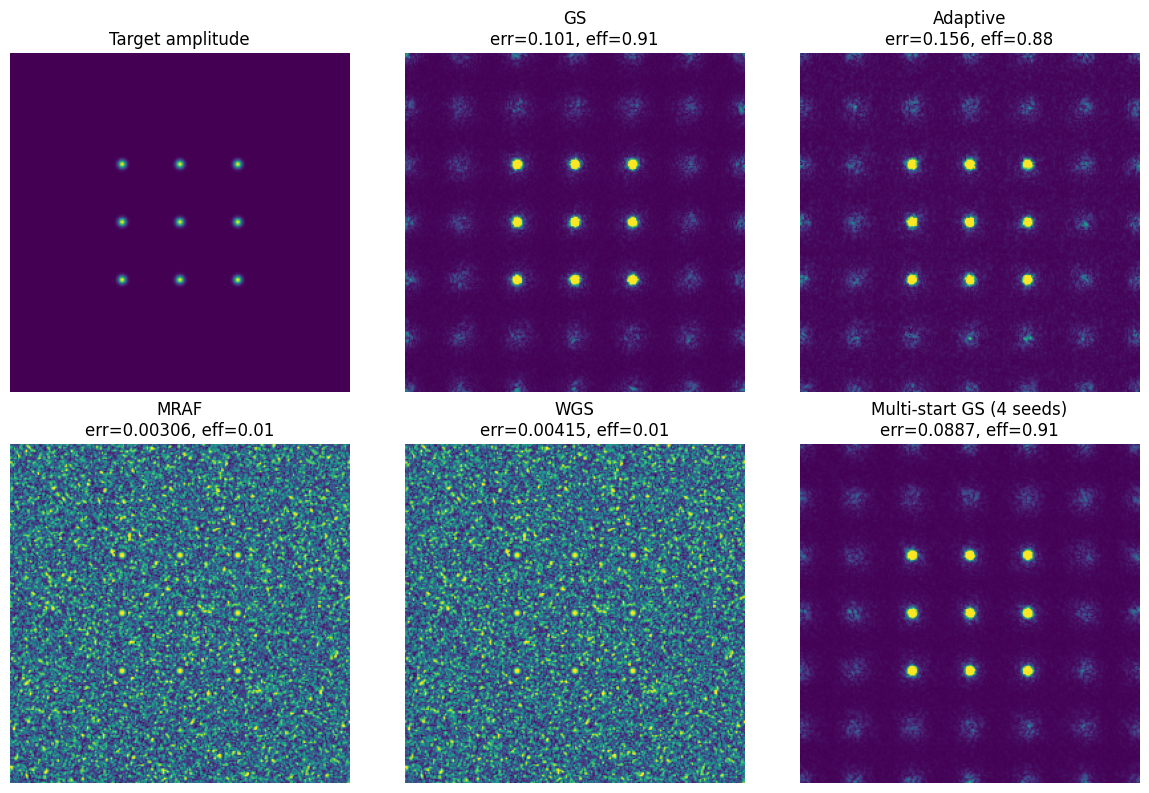

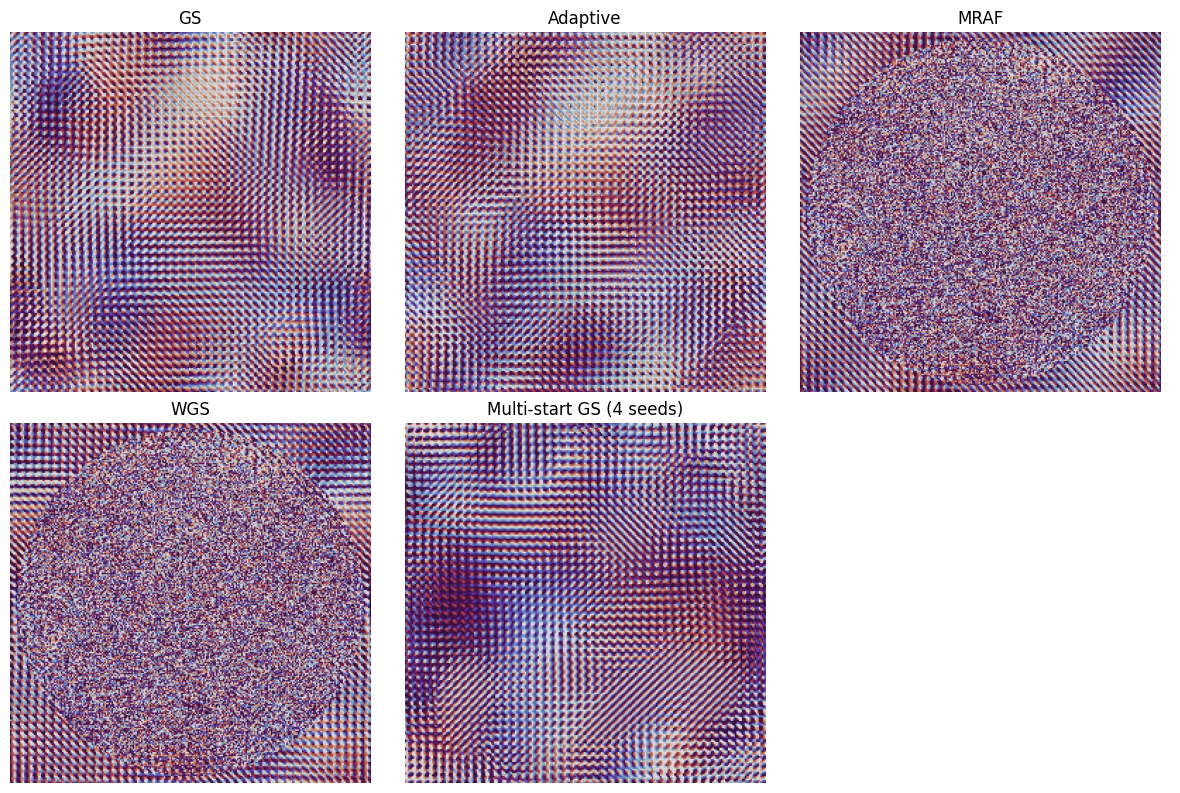

In [8]:
# Default non-interactive benchmark.
# You can edit these values and run this cell again.

target_name = "spots"      # "spots", "ring", "hg11", "letter"
N = 256                    # use 512 for your SLM-sized simulation
iterations = 60
input_kind = "gaussian"    # "gaussian" or "flat"
mask_threshold = 0.08

results = run_benchmark(
    target_name=target_name,
    N=N,
    iterations=iterations,
    input_kind=input_kind,
    seed=DEFAULT_SEED,
    mask_threshold=mask_threshold,
    include_multistart=True,
)

plot_all(results)

## 8. Optional interactive benchmark panel

This panel only runs when you click the button. It should not lock the notebook just because you move a slider.

In [9]:
if HAS_WIDGETS:
    target_dd = widgets.Dropdown(options=["spots", "ring", "hg11", "letter"], value="spots", description="Target:")
    N_dd = widgets.Dropdown(options=[128, 256, 512], value=256, description="Grid N:")
    iter_slider = widgets.IntSlider(value=60, min=5, max=250, step=5, description="Iterations:", continuous_update=False)
    input_dd = widgets.Dropdown(options=["gaussian", "flat"], value="gaussian", description="Input:")
    mask_slider = widgets.FloatSlider(value=0.08, min=0.01, max=0.50, step=0.01, description="Mask thr:", continuous_update=False)
    multistart_cb = widgets.Checkbox(value=True, description="Include multi-start GS")
    run_button = widgets.Button(description="Run benchmark", button_style="primary")
    out = widgets.Output()

    controls = widgets.VBox([
        widgets.HBox([target_dd, N_dd, input_dd]),
        widgets.HBox([iter_slider, mask_slider, multistart_cb]),
        run_button,
    ])

    def on_run_clicked(_):
        global results
        with out:
            clear_output(wait=True)
            print("Running benchmark...")
            results = run_benchmark(
                target_name=target_dd.value,
                N=N_dd.value,
                iterations=iter_slider.value,
                input_kind=input_dd.value,
                seed=DEFAULT_SEED,
                mask_threshold=mask_slider.value,
                include_multistart=multistart_cb.value,
            )
            plot_all(results)

    run_button.on_click(on_run_clicked)
    display(controls, out)
else:
    print("ipywidgets is not installed, so the interactive panel is disabled.")

Output()

## 9. Inspect one method in detail

Use this after running the benchmark.

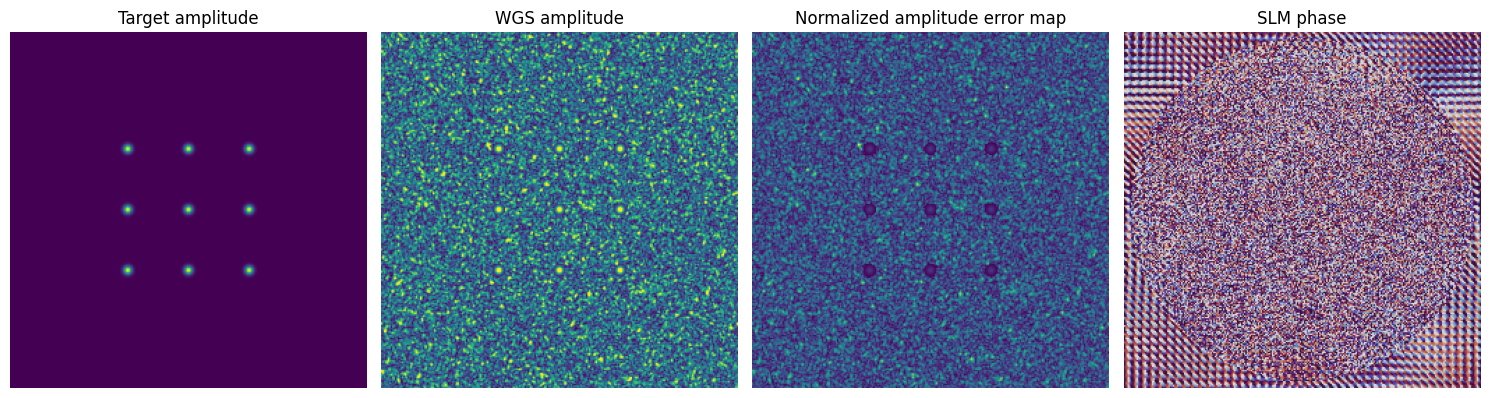

In [10]:
def inspect_method(results: Dict[str, RunResult], method: str = "WGS") -> None:
    r = results[method]
    target_amp = results["_target_amp"]
    recon_amp = np.abs(r.far_field)
    err_map = np.abs(normalize01(recon_amp) - normalize01(target_amp))

    fig, axes = plt.subplots(1, 4, figsize=(15, 4))
    axes[0].imshow(target_amp)
    axes[0].set_title("Target amplitude")
    axes[1].imshow(recon_amp, vmax=np.percentile(recon_amp, 99.5))
    axes[1].set_title(f"{r.name} amplitude")
    axes[2].imshow(err_map)
    axes[2].set_title("Normalized amplitude error map")
    axes[3].imshow(np.mod(r.phase, 2*np.pi), vmin=0, vmax=2*np.pi, cmap="twilight")
    axes[3].set_title("SLM phase")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

inspect_method(results, "WGS")

## 10. Export phase masks

The saved phase is in radians in \([0, 2\pi)\). The `phase_to_uint16()` function maps it to 16-bit values.

For your Meadowlark DVI workflow, the common 24-bit BMP packing is:

- green channel = 8 most significant bits
- red channel = 8 least significant bits
- blue channel ignored

Always verify the LUT and graphics-card mapping experimentally before relying on the exported values.

In [11]:
def phase_to_uint16(phase_rad: np.ndarray) -> np.ndarray:
    phase_wrapped = np.mod(phase_rad, 2*np.pi)
    return np.uint16(np.round(phase_wrapped / (2*np.pi) * 65535))

def uint16_to_meadowlark_dvi_rgb(phase_u16: np.ndarray) -> np.ndarray:
    """
    Pack 16-bit phase into a 24-bit RGB array:
    R = least significant byte
    G = most significant byte
    B = ignored, set to 0
    """
    low = (phase_u16 & 0x00FF).astype(np.uint8)
    high = ((phase_u16 >> 8) & 0x00FF).astype(np.uint8)
    blue = np.zeros_like(low, dtype=np.uint8)
    rgb = np.dstack([low, high, blue])
    return rgb

def save_method_phase_png(results: Dict[str, RunResult], method: str, path: str) -> None:
    if not HAS_PIL:
        raise RuntimeError("Pillow is required to save images.")
    phase_u16 = phase_to_uint16(results[method].phase)
    img = Image.fromarray(phase_u16, mode="I;16")
    img.save(path)
    print(f"Saved 16-bit phase PNG: {path}")

def save_method_phase_meadowlark_bmp(results: Dict[str, RunResult], method: str, path: str) -> None:
    if not HAS_PIL:
        raise RuntimeError("Pillow is required to save images.")
    phase_u16 = phase_to_uint16(results[method].phase)
    rgb = uint16_to_meadowlark_dvi_rgb(phase_u16)
    img = Image.fromarray(rgb, mode="RGB")
    img.save(path)
    print(f"Saved Meadowlark-style packed BMP: {path}")

# Example:
# save_method_phase_png(results, "WGS", "wgs_phase_16bit.png")
# save_method_phase_meadowlark_bmp(results, "WGS", "wgs_phase_meadowlark_dvi.bmp")

## 11. Optional: check whether `slmsuite` is installed

This notebook does not require `slmsuite`, because the goal here is to compare the algorithm ideas transparently. If it is installed, you can later compare these naive implementations with `slmsuite`'s optimized `Hologram` / WGS tools.

In [12]:
try:
    import slmsuite
    print("slmsuite is installed.")
    print("slmsuite module:", slmsuite)
    try:
        from slmsuite.holography.algorithms import Hologram
        print("Imported Hologram from slmsuite.holography.algorithms")
    except Exception as e:
        print("Could not import Hologram from slmsuite.holography.algorithms:", repr(e))
except Exception as e:
    print("slmsuite is not installed in this environment.")
    print("Install it in your notebook environment if you want to compare against the package implementation.")
    print("Import error:", repr(e))

slmsuite is installed.
slmsuite module: <module 'slmsuite' from 'c:\\Users\\Eitan\\Documents\\SLM\\.venv\\Lib\\site-packages\\slmsuite\\__init__.py'>


c:\Users\Eitan\Documents\SLM\.venv\Lib\site-packages\slmsuite\holography\algorithms\_header.py:30: UserWarning: cupy is not installed; using numpy. Install cupy for faster GPU-based holography.
  warnings.warn(


Imported Hologram from slmsuite.holography.algorithms


## 12. Suggested experiments

Try these:

1. Compare `spots` with `ring`. WGS-like methods usually help most for sparse targets.
2. Increase `N` from 256 to 512 and compare runtime.
3. Switch input from `gaussian` to `flat`. A flat input is mathematically easier; a Gaussian input is often more realistic.
4. Change the signal mask threshold. Efficiency depends strongly on what you define as the useful region.
5. Increase `iterations` and watch which methods plateau.
6. Export the final WGS phase and put it through your LUT/SLM path, then compare camera-measured amplitudes with the simulated amplitudes.